In [1]:
import os


In [2]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p /content/local_data

!unzip "/content/drive/MyDrive/VGG_test.zip" -d /content/local_data


Streaming output truncated to the last 5000 lines.
  inflating: /content/local_data/VGG_test/RiceLeafs_merged_224/Rice___Brown_spot/aug_934_train_IMG_3162.jpg  
  inflating: /content/local_data/VGG_test/RiceLeafs_merged_224/Rice___Brown_spot/aug_935_train_IMG_20190424_131056.jpg  
  inflating: /content/local_data/VGG_test/RiceLeafs_merged_224/Rice___Brown_spot/aug_936_train_IMG_20190421_200117.jpg  
  inflating: /content/local_data/VGG_test/RiceLeafs_merged_224/Rice___Brown_spot/aug_937_train_IMG_20190420_194830.jpg  
  inflating: /content/local_data/VGG_test/RiceLeafs_merged_224/Rice___Brown_spot/aug_938_train_IMG_3150.jpg  
  inflating: /content/local_data/VGG_test/RiceLeafs_merged_224/Rice___Brown_spot/aug_939_train_IMG_20190420_191018.jpg  
  inflating: /content/local_data/VGG_test/RiceLeafs_merged_224/Rice___Brown_spot/aug_93_train_IMG_20190420_194651.jpg  
  inflating: /content/local_data/VGG_test/RiceLeafs_merged_224/Rice___Brown_spot/aug_940_train_IMG_20190420_190255.jpg  
  in

In [3]:
!ls /content/local_data
!ls /content/local_data/VGG_test


VGG_test
 augment_minority_classes_plantvillage.py   train_vgg.py
 models_pytorch_5fold			    train_vgg_pytorch_5fold.py
'plantvillage dataset'			    train_vgg_pytorch.py
 RiceLeafs_merged_224			    ugment_minority_classes.py
 train_vgg_merged_5fold_metrics.py


In [4]:
import os

BASE_DIR = "/content/local_data/VGG_test"

PV_DIR   = os.path.join(BASE_DIR, "plantvillage dataset")
RICE_DIR = os.path.join(BASE_DIR, "RiceLeafs_merged_224")


In [5]:
import os, shutil

res_dir = "/content/drive/MyDrive/VGG_test/ResNet_result"
if os.path.exists(res_dir):
    shutil.rmtree(res_dir)
os.makedirs(res_dir, exist_ok=True)
print("Cleaned:", res_dir)


Cleaned: /content/drive/MyDrive/VGG_test/ResNet_result


In [6]:
import os
import json
import copy
import random
import numpy as np
import pandas as pd

import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_fscore_support
)
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 0) الإعدادات والمسارات
# ===============================

print("cuda available? ", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

BASE_DIR = "/content/local_data/VGG_test"
PV_DIR   = os.path.join(BASE_DIR, "plantvillage dataset")
RICE_DIR = os.path.join(BASE_DIR, "RiceLeafs_merged_224")

RESULT_DIR = "/content/drive/MyDrive/VGG_test/ResNet_result"
os.makedirs(RESULT_DIR, exist_ok=True)

RESUME_PATH    = os.path.join(RESULT_DIR, "resnet50_resume_state.json")
FOLD_CSV_PATH  = os.path.join(RESULT_DIR, "resnet50_fold_results.csv")
TRAIN_LOG_PATH = os.path.join(RESULT_DIR, "resnet50_training_log.txt")

IMG_SIZE         = 224
BATCH_SIZE       = 32
TARGET_PER_CLASS = 1200
EPOCHS           = 30
N_SPLITS         = 5
LR               = 1e-4
SEED             = 42
NUM_WORKERS      = 2
EARLY_STOP_PATIENCE  = 5
EARLY_STOP_MIN_DELTA = 0.001
TTA_STEPS        = 5

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[INFO] Using device:", device)

# ===============================
# 1) تحميل الداتا
# ===============================
def load_dataset_from_root(root_dir):
    paths, labels = [], []
    for label in os.listdir(root_dir):
        class_dir = os.path.join(root_dir, label)
        if not os.path.isdir(class_dir):
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                paths.append(os.path.join(class_dir, fname))
                labels.append(label)
    return pd.DataFrame({"path": paths, "label": labels})

print("[INFO] Loading PlantVillage dataset from:", PV_DIR)
df_pv = load_dataset_from_root(PV_DIR)
print(df_pv["label"].value_counts())

print("\n[INFO] Loading Rice dataset from:", RICE_DIR)
df_rice = load_dataset_from_root(RICE_DIR)
print(df_rice["label"].value_counts())

df = pd.concat([df_pv, df_rice], axis=0).reset_index(drop=True)
print("\n[INFO] Total merged dataset:", len(df))

# ===============================
# 2) Balancing — Oversampling + Undersampling
# ===============================
def balance_dataset(df, target_per_class, seed=42):
    parts = []
    for label, group in df.groupby("label"):
        if len(group) < target_per_class:
            sampled = group.sample(n=target_per_class, replace=True, random_state=seed)
        else:
            sampled = group.sample(n=target_per_class, replace=False, random_state=seed)
        parts.append(sampled)
    return pd.concat(parts).reset_index(drop=True)

balanced_df = balance_dataset(df, TARGET_PER_CLASS, SEED)
print("\n[INFO] After balancing:")
print(balanced_df["label"].value_counts())

# ===============================
# 3) إعداد الكلاسات
# ===============================
class_names = sorted(balanced_df["label"].unique())
num_classes  = len(class_names)
label_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_label = {i: name for name, i in label_to_idx.items()}

print("\n[INFO] num_classes =", num_classes)
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")

# ===============================
# 4) Dataset
# ===============================
class PlantDiseaseDataset(Dataset):
    def __init__(self, df, label_to_idx, transform=None):
        self.df = df.reset_index(drop=True)
        self.label_to_idx = label_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.label_to_idx[row["label"]]

# ===============================
# 5) Transforms — Augmentation قوي لصور الموبايل
# ===============================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.4),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

tta_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ===============================
# 6) ResNet50 — كل الـ layers بتتدرب
# ===============================
def build_resnet50(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    for param in model.parameters():
        param.requires_grad = True
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# ===============================
# 7) دوال التدريب والتقييم
# ===============================
def train_one_epoch(model, loader, optimizer, criterion, fold, epoch):
    model.train()
    total_loss, total, correct = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    avg_loss = total_loss / total
    avg_acc  = correct / total
    log_line = f"[Fold {fold}] Epoch {epoch} TRAIN - Loss={avg_loss:.4f}, Acc={avg_acc:.4f}"
    with open(TRAIN_LOG_PATH, "a") as f:
        f.write(log_line + "\n")
    return avg_loss, avg_acc

def eval_one_epoch(model, loader, criterion, fold, epoch, return_probs=False):
    model.eval()
    total_loss, total, correct = 0.0, 0, 0
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            probs   = torch.softmax(outputs, dim=1)
            _, preds = torch.max(probs, 1)
            total_loss += loss.item() * imgs.size(0)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            if return_probs:
                all_probs.extend(probs.cpu().numpy())
    avg_loss = total_loss / total
    avg_acc  = correct / total
    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    if not return_probs:
        log_line = f"[Fold {fold}] Epoch {epoch} VAL   - Loss={avg_loss:.4f}, Acc={avg_acc:.4f}"
        with open(TRAIN_LOG_PATH, "a") as f:
            f.write(log_line + "\n")
    if return_probs:
        return avg_loss, avg_acc, all_labels, all_preds, np.array(all_probs)
    return avg_loss, avg_acc, all_labels, all_preds

def predict_tta(model, dataset, steps=TTA_STEPS):
    model.eval()
    all_labels, all_probs_sum = [], None
    for _ in range(steps):
        probs_run = []
        for i in range(len(dataset)):
            img_path = dataset.df.iloc[i]["path"]
            lbl      = dataset.df.iloc[i]["label"]
            img = Image.open(img_path).convert("RGB")
            x   = tta_transform(img).unsqueeze(0).to(device)
            with torch.no_grad():
                p = torch.softmax(model(x), dim=1).cpu().numpy()[0]
            probs_run.append(p)
            if _ == 0:
                all_labels.append(dataset.label_to_idx[lbl])
        probs_run = np.array(probs_run)
        all_probs_sum = probs_run if all_probs_sum is None else all_probs_sum + probs_run
    all_probs_avg = all_probs_sum / steps
    all_preds = np.argmax(all_probs_avg, axis=1)
    return np.array(all_labels), all_preds, all_probs_avg

# ===============================
# 8) Train/Test split
# ===============================
train_df, test_df = train_test_split(
    balanced_df, test_size=0.2,
    stratify=balanced_df["label"], random_state=SEED
)
print(f"\n[INFO] Train: {len(train_df)} | Test: {len(test_df)}")

test_dataset = PlantDiseaseDataset(test_df, label_to_idx, eval_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# ===============================
# 9) KFold + Resume
# ===============================
train_labels_idx = train_df["label"].map(label_to_idx).values
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

last_completed_fold = 0
if os.path.exists(RESUME_PATH):
    try:
        with open(RESUME_PATH) as f:
            state = json.load(f)
            last_completed_fold = int(state.get("last_completed_fold", 0))
        print(f"[INFO] Resume: last completed fold = {last_completed_fold}")
    except:
        last_completed_fold = 0
else:
    print("[INFO] Starting from Fold 1.")

models_list = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(train_df, train_labels_idx), 1):
    print("\n" + "="*60)
    print(f"[INFO] Fold {fold}/{N_SPLITS}")
    print("="*60)

    if fold <= last_completed_fold:
        print(f"[INFO] Skipping Fold {fold} (already completed).")
        continue

    tr_df = train_df.iloc[tr_idx].reset_index(drop=True)
    va_df = train_df.iloc[val_idx].reset_index(drop=True)

    tr_ds = PlantDiseaseDataset(tr_df, label_to_idx, train_transform)
    va_ds = PlantDiseaseDataset(va_df, label_to_idx, eval_transform)

    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True)
    va_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)

    model     = build_resnet50(num_classes).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_acc  = 0.0
    best_wts  = copy.deepcopy(model.state_dict())
    es_counter = 0

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, tr_loader, optimizer, criterion, fold, epoch)
        va_loss, va_acc, va_lbls, va_preds = eval_one_epoch(model, va_loader, criterion, fold, epoch)

        scheduler.step()

        print(f"Epoch {epoch:02d}: Train={tr_acc:.4f} | Val={va_acc:.4f} | LR={scheduler.get_last_lr()[0]:.2e}")

        if va_acc > best_acc + EARLY_STOP_MIN_DELTA:
            best_acc   = va_acc
            best_wts   = copy.deepcopy(model.state_dict())
            es_counter = 0
        else:
            es_counter += 1
            if es_counter >= EARLY_STOP_PATIENCE:
                print(f"[INFO] Early stopping at epoch {epoch} (patience={EARLY_STOP_PATIENCE})")
                break

    model.load_state_dict(best_wts)

    _, _, va_lbls, va_preds = eval_one_epoch(model, va_loader, criterion, fold, "FINAL")
    acc  = accuracy_score(va_lbls, va_preds)
    prec = precision_score(va_lbls, va_preds, average="macro", zero_division=0)
    rec  = recall_score(va_lbls, va_preds, average="macro", zero_division=0)
    f1   = f1_score(va_lbls, va_preds, average="macro", zero_division=0)

    print(f"[Fold {fold}] Val Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f}")

    fold_path = os.path.join(RESULT_DIR, f"resnet50_fold{fold}_best.pth")
    torch.save(model.state_dict(), fold_path)
    print(f"[INFO] Saved: {fold_path}")

    row = {
        "fold": fold, "val_acc": float(acc),
        "val_precision": float(prec), "val_recall": float(rec), "val_f1": float(f1),
        "best_val_acc": float(best_acc),
        "num_train_samples": len(tr_df), "num_val_samples": len(va_df)
    }
    if os.path.exists(FOLD_CSV_PATH):
        fold_df_csv = pd.read_csv(FOLD_CSV_PATH)
        fold_df_csv = pd.concat([fold_df_csv, pd.DataFrame([row])], axis=0)
        fold_df_csv.to_csv(FOLD_CSV_PATH, index=False)
    else:
        pd.DataFrame([row]).to_csv(FOLD_CSV_PATH, index=False)

    with open(RESUME_PATH, "w") as f:
        json.dump({"last_completed_fold": fold}, f)

    models_list.append((fold, model))

print("\n" + "="*60)
print("[INFO] Cross-validation finished.")
print("="*60)

# ===============================
# 10) اختيار أفضل fold
# ===============================
fold_df_csv = pd.read_csv(FOLD_CSV_PATH)
print("\n[INFO] 5-Fold Results:")
for _, r in fold_df_csv.sort_values("fold").iterrows():
    print(f"  Fold {int(r['fold'])}: Acc={r['val_acc']:.4f} | F1={r['val_f1']:.4f}")

print(f"\n  Mean Acc : {fold_df_csv['val_acc'].mean():.4f} ± {fold_df_csv['val_acc'].std():.4f}")
print(f"  Mean F1  : {fold_df_csv['val_f1'].mean():.4f}")

best_row       = fold_df_csv.loc[fold_df_csv["val_acc"].idxmax()]
best_fold_idx  = int(best_row["fold"])
print(f"\n[INFO] Best fold: Fold {best_fold_idx} (Val Acc={best_row['val_acc']:.4f})")

best_model_path = os.path.join(RESULT_DIR, f"resnet50_fold{best_fold_idx}_best.pth")
best_model = build_resnet50(num_classes).to(device)
best_model.load_state_dict(torch.load(best_model_path, map_location=device))

final_path = os.path.join(RESULT_DIR, "resnet50_FINAL_best.pth")
torch.save(best_model.state_dict(), final_path)
print(f"[INFO] Saved final model: {final_path}")

# ===============================
# 11) تقييم TEST بـ TTA
# ===============================
print("\n[INFO] Evaluating on test set with TTA...")
y_true, y_pred, y_probs = predict_tta(best_model, test_dataset, steps=TTA_STEPS)

test_acc  = accuracy_score(y_true, y_pred)
prec_mac  = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec_mac   = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_mac    = f1_score(y_true, y_pred, average="macro", zero_division=0)

print(f"\n[INFO] TEST Accuracy  = {test_acc:.4f}")
print(f"[INFO] TEST Precision = {prec_mac:.4f}")
print(f"[INFO] TEST Recall    = {rec_mac:.4f}")
print(f"[INFO] TEST F1        = {f1_mac:.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, fmt="d",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix – Test (ResNet50 Improved)")
plt.xticks(rotation=90)
plt.tight_layout()
cm_path = os.path.join(RESULT_DIR, "resnet50_confusion_matrix_test.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.close()
print(f"[INFO] Saved confusion matrix: {cm_path}")

y_bin = label_binarize(y_true, classes=np.arange(num_classes))
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={auc(fpr,tpr):.2f})")
plt.plot([0,1],[0,1],"k--")
plt.title("ROC Curve – Test (ResNet50 Improved)")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.legend(fontsize=6)
plt.tight_layout()
roc_path = os.path.join(RESULT_DIR, "resnet50_roc_curve_test.png")
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.close()
print(f"[INFO] Saved ROC curve: {roc_path}")

test_metrics = {
    "test_accuracy": float(test_acc),
    "test_precision_macro": float(prec_mac),
    "test_recall_macro": float(rec_mac),
    "test_f1_macro": float(f1_mac),
    "num_test_samples": int(len(y_true)),
    "best_fold": best_fold_idx,
    "tta_steps": TTA_STEPS
}
metrics_path = os.path.join(RESULT_DIR, "resnet50_final_test_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(test_metrics, f, indent=4)
print(f"[INFO] Saved test metrics: {metrics_path}")

# اطبع ترتيب الكلاسات عشان تتأكد من app.py
print("\n[INFO] Class order (copy this to app.py):")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")


cuda available?  True
GPU name: NVIDIA L4
[INFO] Using device: cuda
[INFO] Loading PlantVillage dataset from: /content/local_data/VGG_test/plantvillage dataset
label
Orange___Haunglongbing_(Citrus_greening)              5507
Tomato___Tomato_Yellow_Leaf_Curl_Virus                5357
Soybean___healthy                                     5090
Peach___Bacterial_spot                                2297
Tomato___Bacterial_spot                               2127
Tomato___Late_blight                                  1909
Squash___Powdery_mildew                               1835
Tomato___Septoria_leaf_spot                           1771
Tomato___Spider_mites Two-spotted_spider_mite         1676
Apple___healthy                                       1645
Tomato___healthy                                      1591
Blueberry___healthy                                   1502
Peach___healthy                                       1500
Cherry_(including_sour)___Powdery_mildew              1500
Strawber

100%|██████████| 97.8M/97.8M [00:00<00:00, 222MB/s]


Epoch 01: Train=0.8159 | Val=0.9454 | LR=9.97e-05
Epoch 02: Train=0.9305 | Val=0.9650 | LR=9.89e-05
Epoch 03: Train=0.9412 | Val=0.9663 | LR=9.76e-05
Epoch 04: Train=0.9511 | Val=0.9748 | LR=9.57e-05
Epoch 05: Train=0.9547 | Val=0.9701 | LR=9.33e-05
Epoch 06: Train=0.9577 | Val=0.9762 | LR=9.05e-05
Epoch 07: Train=0.9634 | Val=0.9716 | LR=8.72e-05
Epoch 08: Train=0.9640 | Val=0.9753 | LR=8.35e-05
Epoch 09: Train=0.9675 | Val=0.9756 | LR=7.94e-05
Epoch 10: Train=0.9684 | Val=0.9800 | LR=7.50e-05
Epoch 11: Train=0.9710 | Val=0.9754 | LR=7.03e-05
Epoch 12: Train=0.9713 | Val=0.9766 | LR=6.55e-05
Epoch 13: Train=0.9734 | Val=0.9809 | LR=6.04e-05
Epoch 14: Train=0.9760 | Val=0.9834 | LR=5.52e-05
Epoch 15: Train=0.9764 | Val=0.9823 | LR=5.00e-05
Epoch 16: Train=0.9785 | Val=0.9816 | LR=4.48e-05
Epoch 17: Train=0.9803 | Val=0.9843 | LR=3.96e-05
Epoch 18: Train=0.9819 | Val=0.9834 | LR=3.45e-05
Epoch 19: Train=0.9824 | Val=0.9833 | LR=2.97e-05
[INFO] Early stopping at epoch 19 (patience=5)
[Fo

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=True,
    xticks_rotation=90
)

plt.title("Confusion Matrix – Test (ResNet50 Advanced)", fontsize=16)
plt.tight_layout()

cm_sklearn_path = os.path.join(RESULT_DIR, "resnet50_adv_confusion_matrix_test_sklearn.png")
plt.savefig(cm_sklearn_path, dpi=300, bbox_inches="tight")
plt.close()

print("[INFO] Saved sklearn-style confusion matrix at:", cm_sklearn_path)


[INFO] Saved sklearn-style confusion matrix at: /content/drive/MyDrive/VGG_test/ResNet_result/resnet50_adv_confusion_matrix_test_sklearn.png


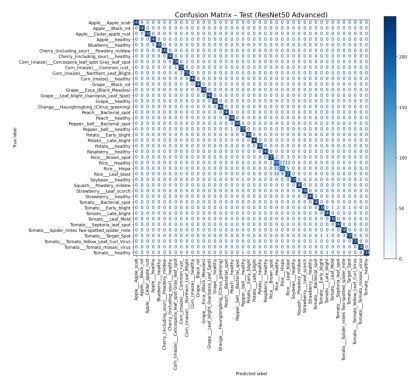

In [18]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img_path = "/content/drive/MyDrive/VGG_test/ResNet_result/resnet50_adv_confusion_matrix_test_sklearn.png"

img = mpimg.imread(img_path)
plt.imshow(img)
plt.axis("off")
plt.show()

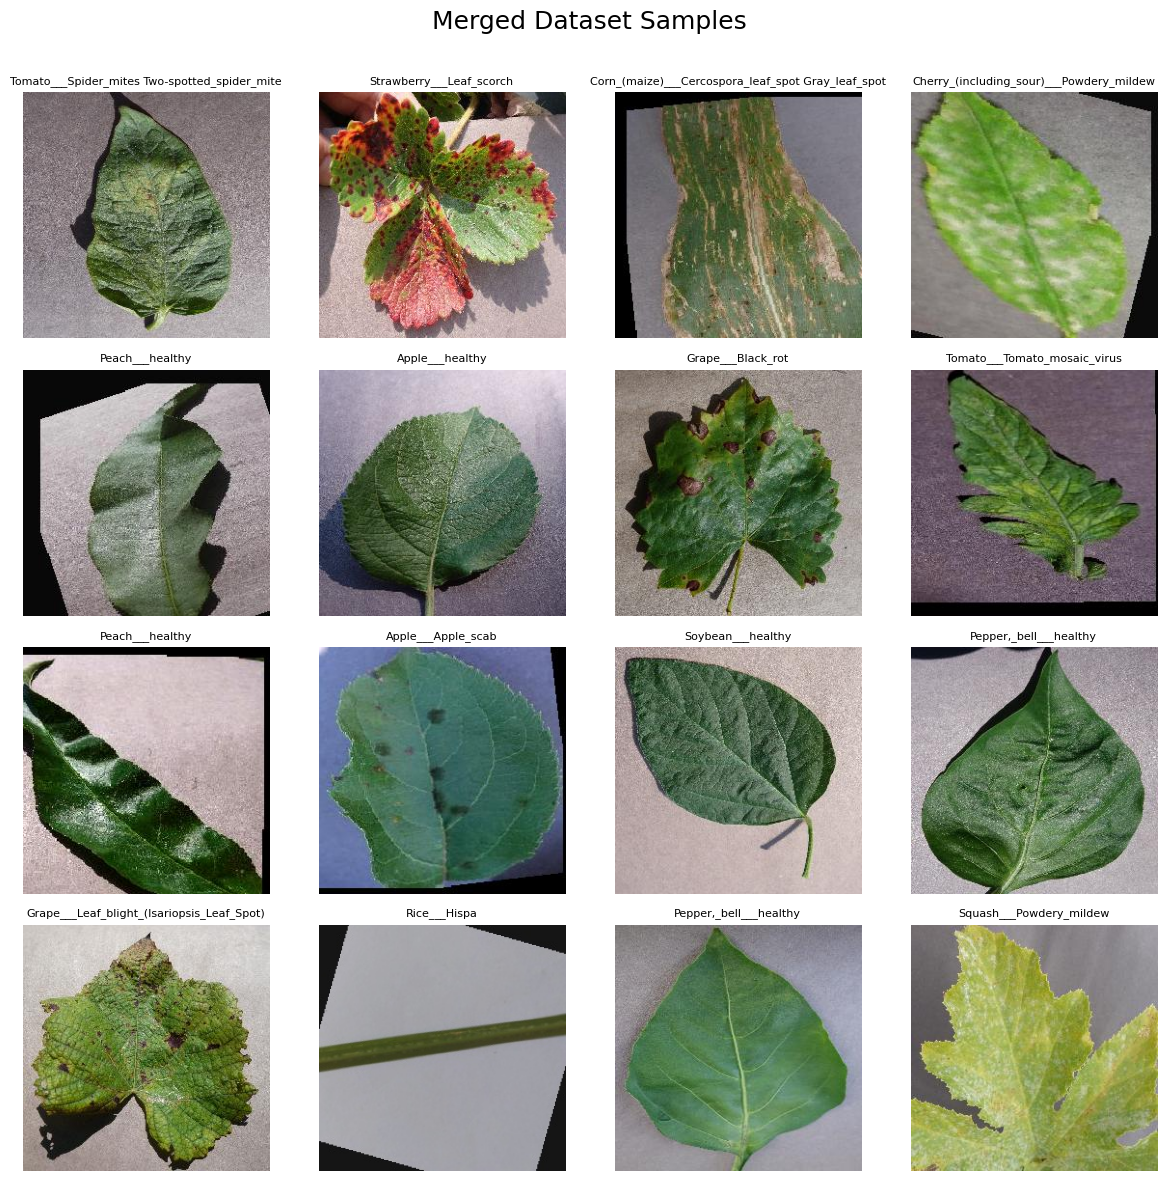

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def show_samples_grid(df, rows=4, cols=4, title="Dataset Samples"):
    sample_df = df.sample(rows * cols, random_state=42)

    plt.figure(figsize=(12, 12))
    plt.suptitle(title, fontsize=18)

    for i, (_, row) in enumerate(sample_df.iterrows()):
        img = Image.open(row["path"]).convert("RGB")

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(row["label"], fontsize=8)
        plt.axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


# مثال التشغيل:
# show_samples_grid(df_pv, title="PlantVillage Sample Images")
# show_samples_grid(df_rice, title="Rice Dataset Sample Images")

# أو للنسخة المدموجة:
show_samples_grid(balanced_df, title="Merged Dataset Samples")


Epochs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Train Acc len: 29 Val Acc len: 29


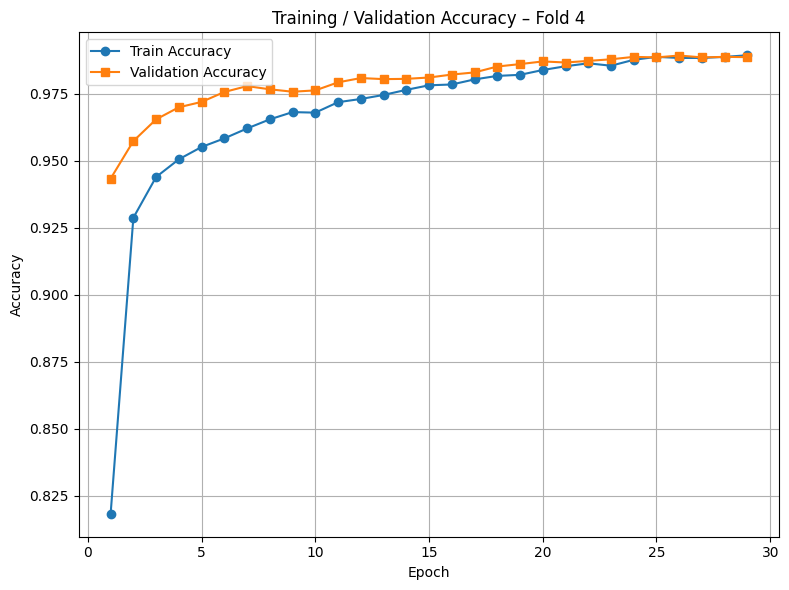

Saved accuracy curve at: /content/drive/MyDrive/VGG_test/ResNet_result/fold4_train_val_accuracy.png


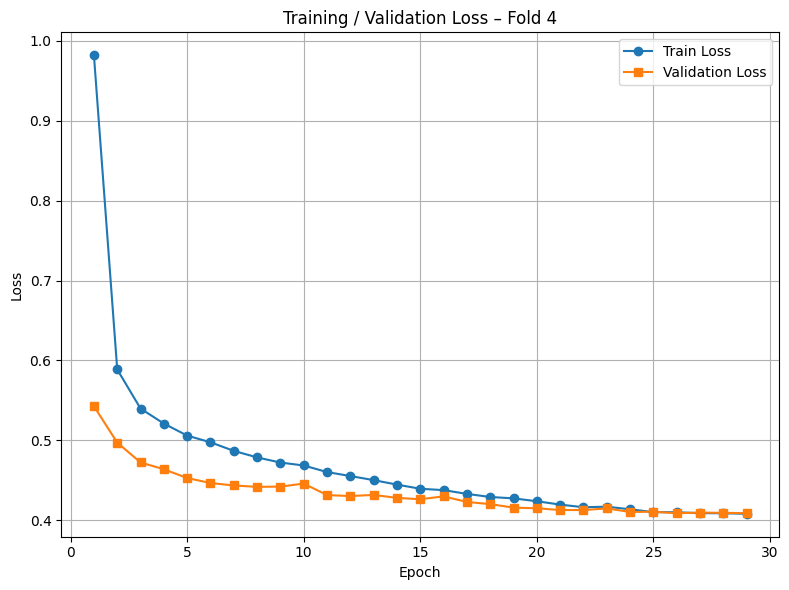

Saved loss curve at: /content/drive/MyDrive/VGG_test/ResNet_result/fold4_train_val_loss.png


In [19]:
import os
import re
import matplotlib.pyplot as plt

RESULT_DIR = "/content/drive/MyDrive/VGG_test/ResNet_result"
LOG_PATH   = os.path.join(RESULT_DIR, "resnet50_training_log.txt")

best_fold = 4  # لو عايز تغير الفولد بعدين عدّل الرقم ده

epochs = []
train_acc, val_acc = [], []
train_loss, val_loss = [], []

with open(LOG_PATH, "r") as f:
    for line in f:
        if f"[Fold {best_fold}]" not in line:
            continue

        # نجيب رقم الإيبوك
        m_epoch = re.search(r"Epoch\s+(\d+)", line)
        m_vals  = re.search(r"Loss=([0-9.]+), Acc=([0-9.]+)", line)
        if not (m_epoch and m_vals):
            continue

        epoch = int(m_epoch.group(1))
        loss  = float(m_vals.group(1))
        acc   = float(m_vals.group(2))

        if "TRAIN" in line:
            epochs.append(epoch)
            train_loss.append(loss)
            train_acc.append(acc)
        elif "VAL" in line:
            val_loss.append(loss)
            val_acc.append(acc)

print("Epochs:", epochs)
print("Train Acc len:", len(train_acc), "Val Acc len:", len(val_acc))

# تأكد إن الأطوال متساوية
min_len = min(len(train_acc), len(val_acc))
epochs_plot = epochs[:min_len]
train_acc   = train_acc[:min_len]
val_acc     = val_acc[:min_len]
train_loss  = train_loss[:min_len]
val_loss    = val_loss[:min_len]

# --------- Curve 1: Accuracy ---------
plt.figure(figsize=(8, 6))
plt.plot(epochs_plot, train_acc, marker="o", label="Train Accuracy")
plt.plot(epochs_plot, val_acc, marker="s", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Training / Validation Accuracy – Fold {best_fold}")
plt.grid(True)
plt.legend()
plt.tight_layout()

acc_curve_path = os.path.join(RESULT_DIR, f"fold{best_fold}_train_val_accuracy.png")
plt.savefig(acc_curve_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved accuracy curve at:", acc_curve_path)

# --------- Curve 2: Loss ---------
plt.figure(figsize=(8, 6))
plt.plot(epochs_plot, train_loss, marker="o", label="Train Loss")
plt.plot(epochs_plot, val_loss, marker="s", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training / Validation Loss – Fold {best_fold}")
plt.grid(True)
plt.legend()
plt.tight_layout()

loss_curve_path = os.path.join(RESULT_DIR, f"fold{best_fold}_train_val_loss.png")
plt.savefig(loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved loss curve at:", loss_curve_path)


In [10]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report

# نولد الريبورت كـ dict
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

# نحوله DataFrame عشان نعرضه كويس
report_df = pd.DataFrame(report_dict).T

# نعمل شوية فورمات للأرقام (اختياري)
report_df[["precision", "recall", "f1-score"]] = report_df[["precision", "recall", "f1-score"]].round(2)
if "support" in report_df.columns:
    report_df["support"] = report_df["support"].astype(int)

# نرسمه كـ جدول في صورة
fig, ax = plt.subplots(figsize=(10, 16))  # ممكن تكبر/تصغر على حسب عدد الكلاسات
ax.axis("off")
table = ax.table(
    cellText=report_df.values,
    rowLabels=report_df.index,
    colLabels=report_df.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(6)      # زوّد الرقم لو عايز الخط أكبر
table.scale(1.2, 1.2)      # تحكم في حجم الجدول

plt.title("Classification Report – ResNet50 Advanced", fontsize=10, pad=10)

# مسار الحفظ
rep_img_path = os.path.join(RESULT_DIR, "classification_report_snapshot.png")
plt.savefig(rep_img_path, dpi=300, bbox_inches="tight")
plt.close()

print("Saved classification report snapshot at:", rep_img_path)


Saved classification report snapshot at: /content/drive/MyDrive/VGG_test/ResNet_result/classification_report_snapshot.png


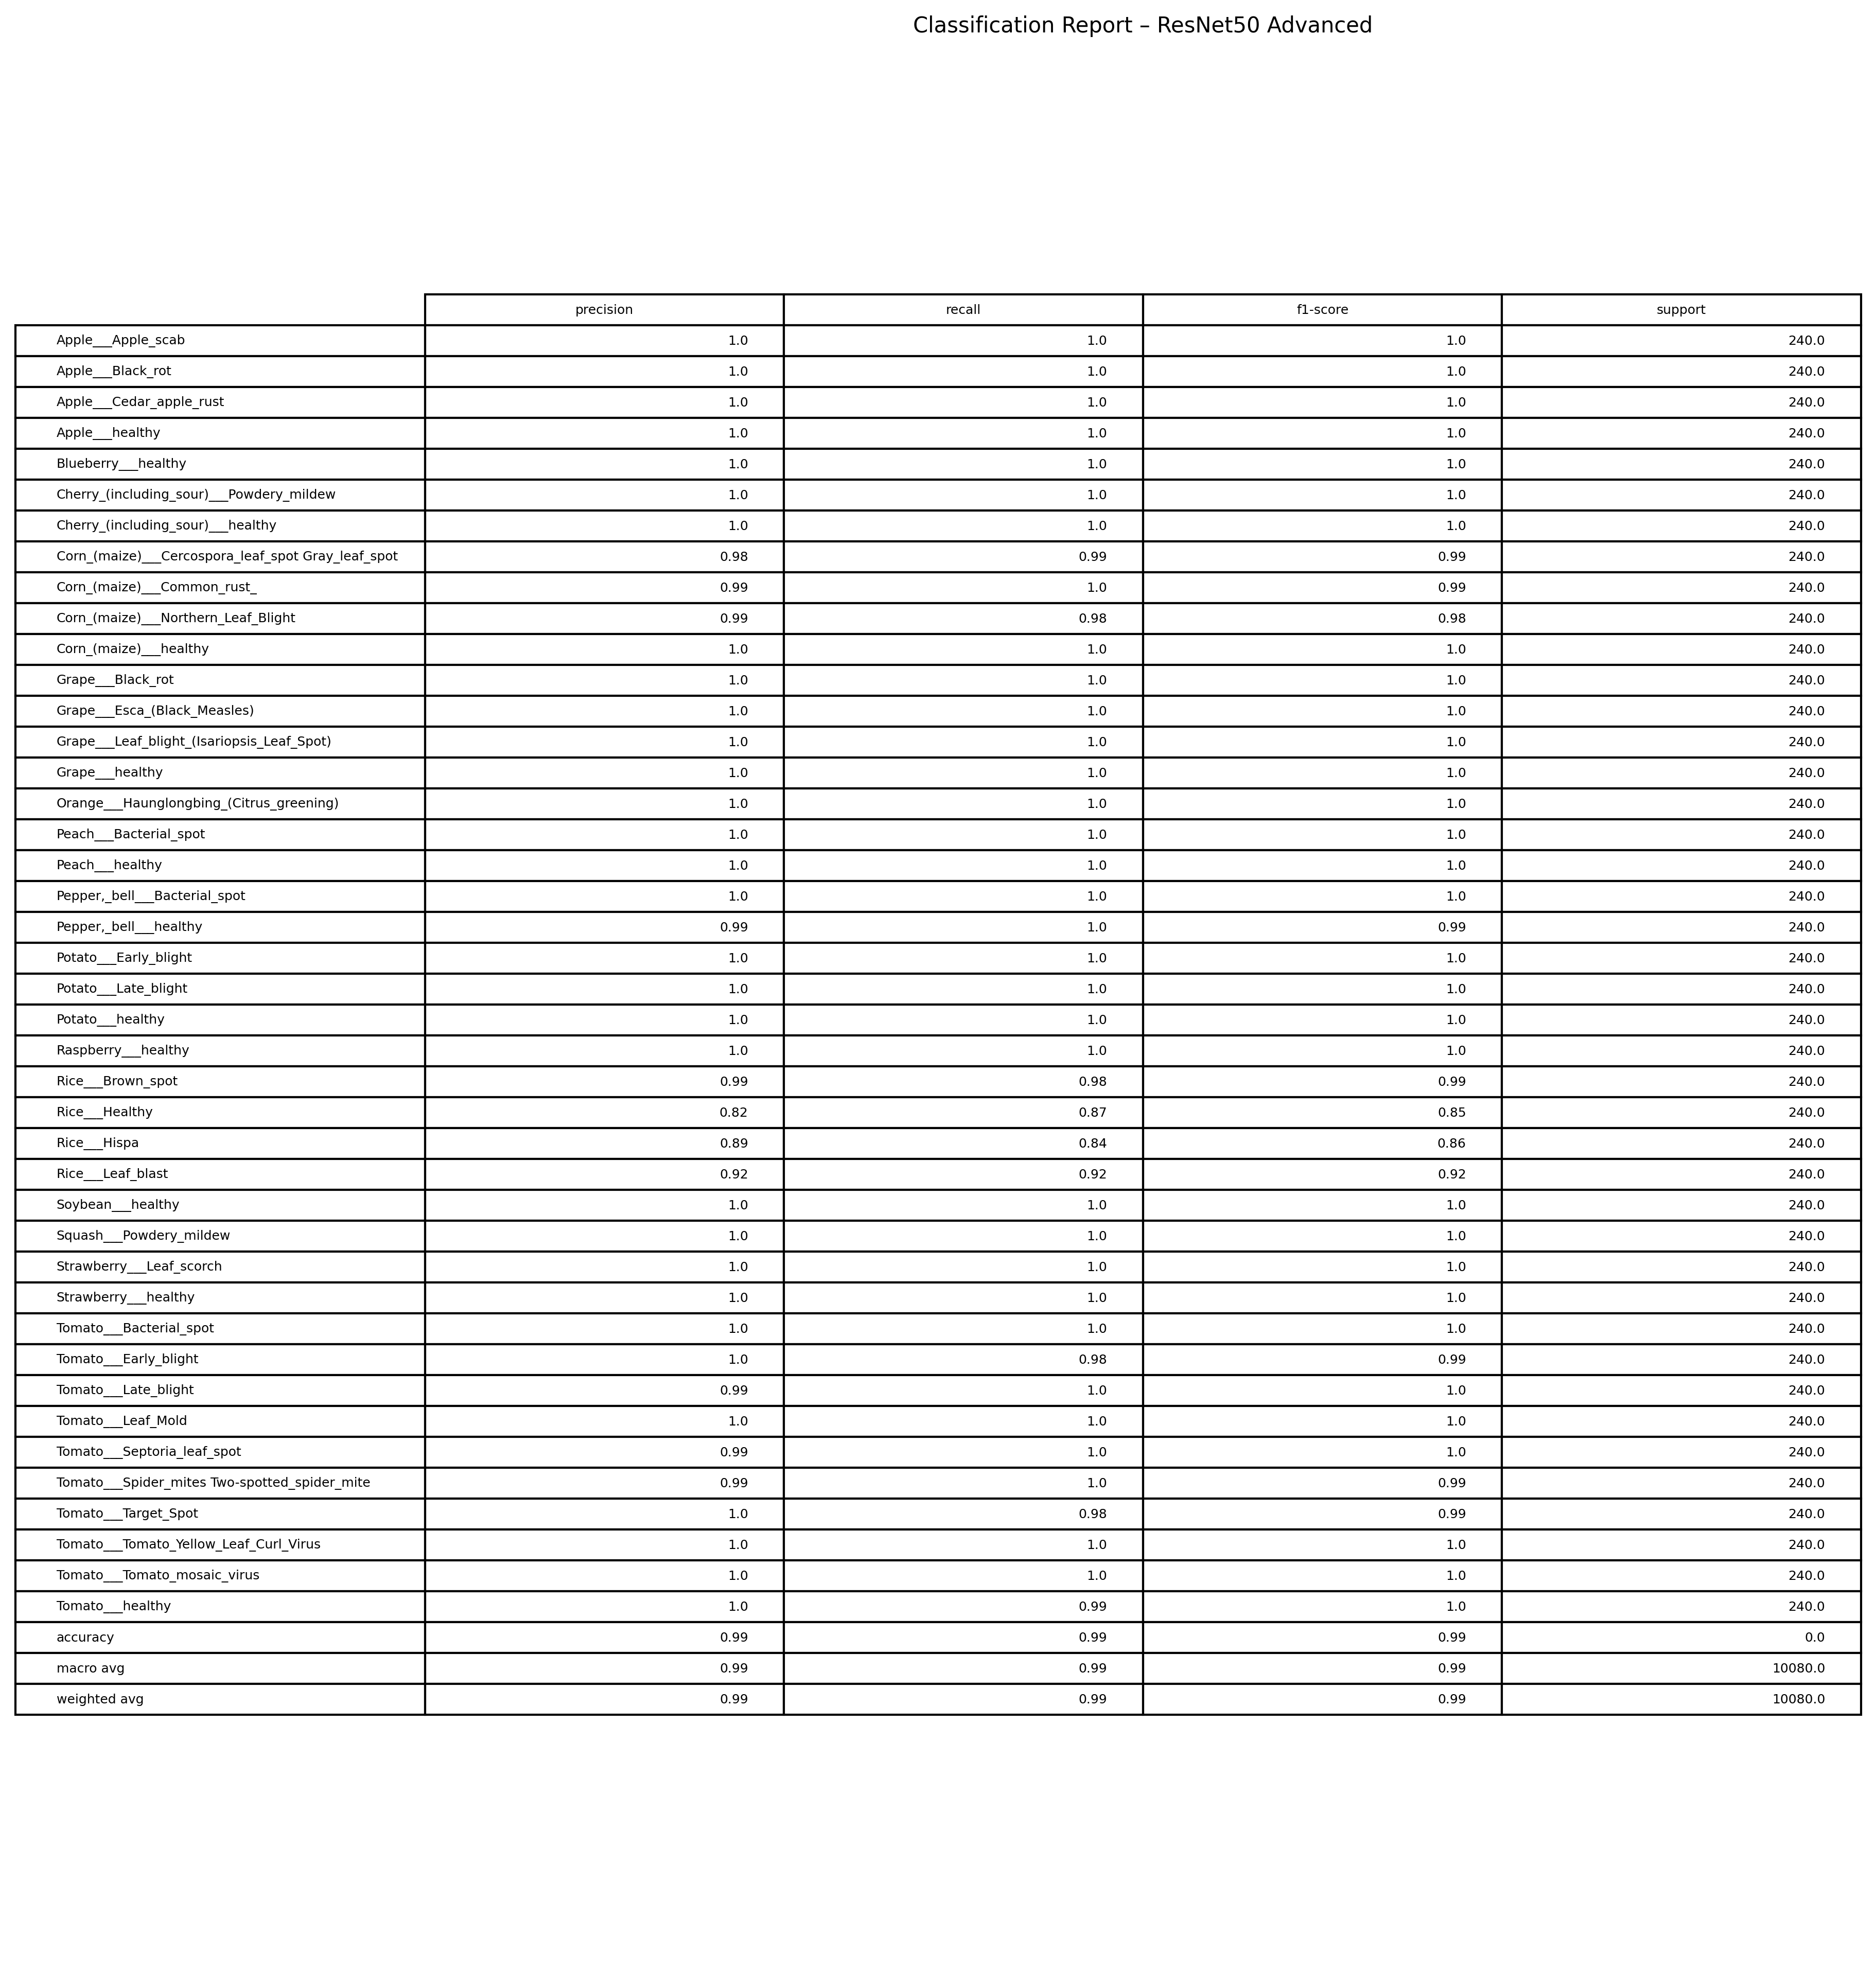

In [14]:
from IPython.display import Image, display

img_path = "/content/drive/MyDrive/VGG_test/ResNet_result/classification_report_snapshot.png"
display(Image(filename=img_path))

In [11]:
import torch
print("GPU name:", torch.cuda.get_device_name(0))


GPU name: NVIDIA L4


In [ ]:
!pip install gradio -q


In [20]:

import gradio as gr
import torch
from PIL import Image
import numpy as np
from torchvision import transforms, models
from torch import nn

# --- Re-defining dependencies from previous cells ---
IMG_SIZE    = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_names = [
    "Apple___Apple_scab", "Apple___Black_rot", "Apple___Cedar_apple_rust", "Apple___healthy",
    "Blueberry___healthy", "Cherry_(including_sour)___Powdery_mildew", "Cherry_(including_sour)___healthy",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot", "Corn_(maize)___Common_rust_",
    "Corn_(maize)___Northern_Leaf_Blight", "Corn_(maize)___healthy", "Grape___Black_rot",
    "Grape___Esca_(Black_Measles)", "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)", "Grape___healthy",
    "Orange___Haunglongbing_(Citrus_greening)", "Peach___Bacterial_spot", "Peach___healthy",
    "Pepper,_bell___Bacterial_spot", "Pepper,_bell___healthy", "Potato___Early_blight",
    "Potato___Late_blight", "Potato___healthy", "Raspberry___healthy", "Rice___Brown_spot",
    "Rice___Healthy", "Rice___Hispa", "Rice___Leaf_blast", "Soybean___healthy",
    "Squash___Powdery_mildew", "Strawberry___Leaf_scorch", "Strawberry___healthy",
    "Tomato___Bacterial_spot", "Tomato___Early_blight", "Tomato___Late_blight",
    "Tomato___Leaf_Mold", "Tomato___Septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite", "Tomato___Target_Spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus", "Tomato___Tomato_mosaic_virus", "Tomato___healthy"
]

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def build_resnet50(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # Freeze all layers initially
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze the last block (layer4) and the fully connected layer (fc)
    for name, param in model.named_parameters():
        if name.startswith("layer4") or name.startswith("fc"):
            param.requires_grad = True

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

# ---------- Load Best Model ----------
num_classes = len(class_names)
model = build_resnet50(num_classes)

best_model_path = "/content/drive/MyDrive/VGG_test/ResNet_result/resnet50_fold3_best.pth"
state_dict = torch.load(best_model_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

# ---------- Helper Function ----------
def parse_class_name(cls_name):
    parts = cls_name.split("___")
    if len(parts) == 2:
        plant, disease = parts[0], parts[1]
    else:
        plant, disease = cls_name, "N/A"
    return plant, disease

# ---------- Prediction Function (Top‑1 only) ----------
def predict_plant_disease(image):
    if image is None:
        return "No image provided."

    img = image.convert("RGB")
    x = eval_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(x)
        probs = torch.softmax(outputs, dim=1)[0].cpu().numpy()

    top_idx = int(np.argmax(probs))
    top_prob = float(probs[top_idx])
    top_class = class_names[top_idx]
    plant, disease = parse_class_name(top_class)

    txt = (
        f"Prediction:\n"
        f"- Plant: {plant}\n"
        f"- Disease: {disease}\n"
        f"- Confidence: {top_prob*100:.2f}%"
    )

    return txt

# ---------- Gradio GUI ----------
demo = gr.Interface(
    fn=predict_plant_disease,
    inputs=gr.Image(type="pil", label="Upload leaf image"),
    outputs=gr.Textbox(label="Prediction"),
    title="Plant Disease Classifier – ResNet50",
    description="Upload a plant leaf image. The model will predict the plant type and disease."
)

demo.launch(debug=True)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 226MB/s]


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://3eb265d4759123150e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://3eb265d4759123150e.gradio.live
